<div>
<a href="https://www.audiolabs-erlangen.de/fau/professor/mueller"><img src="data_layout/PCPT_Teaser.png" width=100% style="float: right;" alt="PCPT Teaser"></a>
</div>

# Unit 6: Convolution and CNNs

<ul>
    <li><a href='#learn' style="color:#E65100;"><strong>Overview and Learning Objectives</strong></a></li> 
    <li><a href='#intro1Dconv' style="color:black;">Introduction to 1D Convolution</a></li>
    <li><a href='#background_convolution_math' style="color:#1B5E20;"><strong>Background:</strong> Discrete Convolution in Sequence Spaces</a></li>     
    <li><a href='#convolutionpytorch' style="color:black;">Convolution in PyTorch</a></li>    
    <li><a href='#example_smoothing' style="color:black;">Example: Denoising with a Convolutional Filter</a></li>
    <li><a href='#background_low_band_high' style="color:#1B5E20;"><strong>Background:</strong> Low-, Band-, and High-Pass Filters</a></li>     
    <li><a href='#pytorch_dataset' style="color:black;">Working with Datasets in PyTorch</a></li>     
    <li><a href='#pytorch_dataloader' style="color:black;">Working with Data Loaders in PyTorch</a></li>     
    <li><a href='#exercise_convolution_smooth_edge' style="color:#006064;"><strong>Exercise 1:</strong> Convolution for Smoothing and Edge Detection</a></li> 
    <li><a href='#exercise_conv1d_parameters' style="color:#006064;"><strong>Exercise 2:</strong> Understanding Key Parameters of the PyTorch 1D Convolution Layer</a></li>    
    <li><a href='#exercise_convolution_freq_separation' style="color:#006064;"><strong>Exercise 3:</strong> Learning to Separate Low- and High-Frequency Components</a></li>    
</ul>  

<a id='learn'></a>
<div style="
  background-color: #FFE0B2A0;
  border: 1px solid #FFC671A0;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<h2 style="color:#E65100;">Overview and Learning Objectives</h2>

<p style="color:#E65100;">
This unit introduces the foundational concept of <strong>convolution</strong> as a building block for signal processing and deep learning with PyTorch. Focusing on <strong>1D convolution</strong>, the unit develops both theoretical understanding and practical skills for applying convolutional filters to time-series data such as audio signals. Learners will explore the mathematical basis of discrete convolution, understand how it differs from correlation, and gain hands-on experience using <code>torch.nn.Conv1d</code> to implement both fixed and learnable filters. A motivating application throughout the unit is <strong>signal denoising</strong>, where convolution is used to suppress noise while preserving important signal features. The learning objectives of this unit are as follows:
</p>

<ul style="color:#E65100;">
<li>Explain the mathematical definition of discrete 1D convolution and contrast it with cross-correlation in frameworks like PyTorch.</li>
<li>Configure convolutional layers using <code>torch.nn.Conv1d</code>, focusing on parameters such as <code>kernel_size</code>, <code>padding</code>, <code>stride</code>, and <code>dilation</code>.</li>
<li>Apply convolutional filters for signal smoothing, edge detection, and denoising using both fixed and learned kernels.</li>
<li>Analyze the roles of <strong>low-pass</strong>, <strong>high-pass</strong>, and <strong>band-pass</strong> filters in relation to frequency content.</li>
<li>Describe how filter weights are learned from data through gradient descent, and visualize the effect of trained filters on unseen signals.</li>
<li>Use PyTorch's <code>Dataset</code> and <code>DataLoader</code> abstractions to efficiently structure and batch input&ndash;target signal pairs.</li>
</ul>

<p style="color:#E65100;">
The unit includes three hands-on exercises:  
</p>
<ul style="color:#E65100;">
<li><a href="#exercise_convolution_smooth_edge">Exercise 1</a>: Apply smoothing and edge detection with fixed filters.</li>
<li><a href="#exercise_conv1d_parameters">Exercise 2</a>: Explore key convolutional parameters.</li>
<li><a href="#exercise_convolution_freq_separation">Exercise 3</a>: Learn to extract high-frequency signals from noise.</li>
</ul>

<p style="color:#E65100;">
Together, these tasks build intuition for how 1D convolution operates in practice. For details, see the <a href="https://pytorch.org/docs/stable/generated/torch.nn.Conv1d.html" target="_blank">PyTorch documentation on <code>nn.Conv1d</code></a>.
</p>
</div>

In [1]:
# --- Core scientific stack ---
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

# --- Custom utilities (Unit 6) ---
from libpcpt.unit06 import (
    plot_signal_denoise,
    visualize_pairs_24,
    plot_filter_kernel,
    visualize_further_examples_6,
    exercise_convolution_smooth_edge,
    exercise_conv1d_parameters,
    exercise_convolution_freq_separation
)

<a id='intro1Dconv'></a> 
## Introduction to 1D Convolution
Convolution is a fundamental operation in mathematics, signal processing, and deep learning. In the one-dimensional discrete case, the **convolution** of a **signal** $x$ with a **kernel** $h$ produces a new signal $y$, defined as:

$$
y(n) = (x * h)(n) = \sum_{k=-\infty}^{\infty} x(k) \cdot h(n - k)
$$

This operation performs a sliding, weighted summation over the input signal, where the weights are determined by the kernel $h$. In signal processing, convolution is widely used as a filtering technique to **smooth**, **sharpen**, or **extract features** from signals. Key properties of convolution include:

* **Linearity**: Convolution is a linear operation.
* **Translational equivariance**: A shift in the input signal results in an equivalent shift in the output.
* **Locality**: Each output value depends only on a local neighborhood of the input.

In practical settings, we assume signals and kernels are of **finite length**:

- Let `x = [x[0], x[1], ..., x[N-1]]` be a 1D input signal of length `N`.
- Let `h = [h[0], h[1], ..., h[K-1]]` be a 1D convolution kernel of length `K`.

Then the output signal `y` has length `N + K - 1`, assuming **zero-padding** is applied to extend `x` beyond its original length with zeros. This ensures that all shifts of `h` can be applied even near the boundaries of `x`. The following code snippet demonstrates the discrete convolution of `x` with `h`, including zero-padding, and displays the resulting signal.

In [2]:
# Set manual seed for reproducibility
torch.manual_seed(0)
np.random.seed(0)

# Input signal and kernel
x = np.array([1, 2, 3, 4])
h = np.array([1, 2, 3])

# Perform convolution
y = np.convolve(x, h)

# Output
print(f"{'Input signal x:':<20} length: {len(x):<2}  | values: {x}")
print(f"{'Kernel h:':<20} length: {len(h):<2}  | values: {h}")
print(f"{'Output y = x * h:':<20} length: {len(y):<2}  | values: {y}")

Input signal x:      length: 4   | values: [1 2 3 4]
Kernel h:            length: 3   | values: [1 2 3]
Output y = x * h:    length: 6   | values: [ 1  4 10 16 17 12]


### Convolution Modes in NumPy

By default, `np.convolve` returns the **full discrete convolution**, producing an output of length `N + K − 1`, where the signal is effectively extended by the kernel's duration minus one. This corresponds to **zero-padding** beyond the signal boundaries. In many applications, however, alternative padding strategies (or no padding) are preferred. Without padding, the output is shorter, since the kernel is only applied where it fully overlaps with the input (i.e., **valid shifts**). NumPy's `np.convolve` supports the following modes:

- The `full` mode (default) returns the complete convolution, including all positions where the kernel overlaps (partially or fully) with the input. The output has length `N + K − 1`.

- The `valid` mode includes only positions where the kernel fully fits within the input, without any padding. The output is shorter, with length `N − K + 1`.

- The `same` mode produces an output of the same length `N` as the input, centered relative to the full result. Padding is applied as needed.

Here are some examples:

In [3]:
# Input signal and kernel
x_np = np.array([1.0, 2.0, 3.0, 4.0])
h_np = np.array([1.0, 2.0, 3.0])

# Perform convolution in different modes
y_full = np.convolve(x, h, mode='full')
y_valid = np.convolve(x, h, mode='valid')
y_same = np.convolve(x, h, mode='same')

# Output
print(f"{'Input signal x:':<20} length: {len(x):<2}  | values: {x}")
print(f"{'Kernel h:':<20} length: {len(h):<2}  | values: {h}\n")
print(f"{'y with full mode:':<20} length: {len(y_full):<2}  | values: {y_full}")
print(f"{'y with valid mode:':<20} length: {len(y_valid):<2}  | values: {y_valid}")
print(f"{'y with same mode:':<20} length: {len(y_same):<2}  | values: {y_same}")

Input signal x:      length: 4   | values: [1 2 3 4]
Kernel h:            length: 3   | values: [1 2 3]

y with full mode:    length: 6   | values: [ 1  4 10 16 17 12]
y with valid mode:   length: 2   | values: [10 16]
y with same mode:    length: 4   | values: [ 4 10 16 17]


<a id='background_convolution_math'></a>
<div style="
  background-color: #C8E6C9A0;
  border: 1px solid #81C784A0;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<h2 style="color:#1B5E20;">Background: Discrete Convolution in Sequence Spaces</h2>

<p style="color:#1B5E20;">
In mathematics and signal processing, discrete-time signals are modeled as functions $x : \mathbb{Z} \rightarrow \mathbb{C}$. To analyze such signals, we consider them as elements of the <strong>sequence spaces</strong> $\ell^p(\mathbb{Z})$, defined by
$$
\ell^p(\mathbb{Z}) = \bigg\{ x : \mathbb{Z} \to \mathbb{R} \,\Big|\, \|x\|_p := \Big( \sum\nolimits_{n \in \mathbb{Z}} |x(n)|^p \Big)^{1/p} < \infty \bigg\}, \quad 1 \leq p < \infty.
$$
These spaces provide a mathematical framework for studying signals whose overall energy ($p = 2$), absolute sum ($p = 1$), or other aggregate properties (general $p$) are finite. This ensures that the signal values decay as one moves away from the origin in both positive and negative directions, allowing the signal to remain well-behaved and stable&mdash;properties essential for rigorous analysis and reliable processing. A fundamental operation in this context is the <strong>convolution</strong> of two discrete-time signals $x$ and $h$, defined by
$$
(x * h)(n) = \sum\nolimits_{k \in \mathbb{Z}} x(k) \cdot h(n - k)
$$
for $n \in \mathbb{Z}$. This combines $x$ with a flipped and shifted version of $h$ and is widely used for filtering and smoothing. To ensure the sum is well-defined, it suffices for $x$ and $h$ to have <strong>finite support</strong>. More generally, the <strong>Young inequality</strong> guarantees that if $x \in \ell^1(\mathbb{Z})$ and $h \in \ell^p(\mathbb{Z})$ for $1 \leq p \leq \infty$, then the convolution $x * h$ belongs to $\ell^p(\mathbb{Z})$ and satisfies the norm bound
$$
\|x * h\|_p \leq \|x\|_1 \cdot \|h\|_p.
$$
Fixing a kernel $h \in \ell^1(\mathbb{Z})$, we define the <strong>convolution operator</strong> $C_h : \ell^2(\mathbb{Z}) \rightarrow \ell^2(\mathbb{Z})$ via
$$
C_h(x) := h * x.
$$
This operator has the following important properties:
</p>
<ul style="color:#1B5E20;">
<li><strong>Linearity:</strong> For any signals $x, y \in \ell^2(\mathbb{Z})$ and scalars $a, b \in \mathbb{R}$, the operator satisfies
$C_h(ax + by) = a\, C_h(x) + b\, C_h(y)$.</li>

<li><strong>Translational equivariance:</strong> For any signal $x \in \ell^2(\mathbb{Z})$ and integer shift $m \in \mathbb{Z}$, define the time-shifted signal
$x^m$ by $x^m(n) := x(n - m)$. Then, $C_h(x^m) = (C_h(x))^m$.</li>

<li><strong>Impulse response:</strong> Let $\delta : \mathbb{Z} \rightarrow \mathbb{R}$ be the unit impulse signal, defined by $\delta(n) = 1$ for $n = 0$ and $0$ otherwise. Then $C_h(\delta) = h$.</li>
</ul>

<p style="color:#1B5E20;">
In digital signal processing, a system that maps an input signal to an output signal and exhibits linearity and translation equivariance&mdash;often referred to as <strong>time invariance</strong> in the context of systems&mdash;is called a <strong>linear time-invariant</strong> or <strong>LTI</strong> system. If an LTI system $T : \ell^2(\mathbb{Z}) \rightarrow \ell^2(\mathbb{Z})$ is also <strong>stable</strong> (i.e., it maps bounded input signals to bounded output signals), it admits a complete characterization through convolution: Every such operator can be represented as a <strong>convolution operator</strong> of the form  
$$
T = C_h,
$$  
where the kernel is given by $h = T(\delta) \in \ell^1(\mathbb{Z})$. The signal $h$ is called the <strong>impulse response</strong> of $T$, and its entries $h(n)$ are known as the <strong>filter coefficients</strong>. This result establishes a one-to-one correspondence between LTI systems, convolution operators, and sequences in $\ell^1(\mathbb{Z})$. In practice, we often refer to $h$ itself as the <strong>filter</strong> or <strong>filter kernel</strong>.
</p>
</div>

<a id='convolutionpytorch'></a> 
## Convolution in PyTorch

### Convolution vs. Cross-Correlation
In PyTorch, 1D convolution is implemented using `torch.nn.Conv1d`, which applies learnable filters to input tensors. Although these layers are called &ldquo;convolutional,&rdquo; they actually perform **cross-correlation**, meaning the kernel is applied without flipping. This differs from the mathematical definition of convolution, where the kernel is reversed before application.

* **Convolution** flips the kernel:  $(x * h)(n) = \sum_k x(k) \cdot h(n - k)$  
* **Cross-correlation** uses the kernel without flipping:  $y(n) = \sum_k x(k) \cdot h(n + k)$

This design choice simplifies both the forward and backward passes in deep learning frameworks, making implementation and optimization more efficient. From a learning perspective, the difference between convolution and cross-correlation is typically negligible. Since the filter weights are learned during training, the model automatically adapts to the appropriate structure&mdash;regardless of whether the kernel is flipped. Moreover, when the kernel is symmetric (i.e., $h(k) = h(-k)$), convolution and cross-correlation yield the same result, making the distinction irrelevant in such cases.

Internally, `nn.Conv1d` makes use of the low-level function `torch.nn.functional.conv1d` provided by the functional interface. The  module `nn.Conv1d` essentially acts as a wrapper that stores the trainable parameters and applies them using this functional during the forward pass. The following code provides a minimal example comparing NumPy and PyTorch behavior using `F.conv1d`. Details on how to define and use `nn.Conv1d` will be introduced in the subsequent sections.

In [4]:
# Input signal and kernel
x_np = np.array([1.0, 2.0, 3.0, 4.0])
h_np = np.array([1.0, 2.0, 3.0])

# NumPy: True convolution (matches math definition: kernel is flipped)
y_np_conv = np.convolve(x_np, h_np, mode='valid')

# NumPy: Cross-correlation (manually cancel NumPy's internal flip)
y_np_xcorr = np.convolve(x_np, np.flip(h_np), mode='valid')

# Convert input signal and convolution kernel into PyTorch tensors
# shape: (batch=1, channel=1, length=4)
x_pt = torch.tensor(x_np, dtype=torch.float32).view(1, 1, -1)  
 # shape: (channel_out=1, channel_in=1, length=3)
h_pt = torch.tensor(h_np, dtype=torch.float32).view(1, 1, -1) 

# PyTorch: conv1d = cross-correlation (no kernel flip, default behavior)
y_pt = F.conv1d(x_pt, h_pt, bias=None)

# Output comparison
print(f"{'Input signal x:':<28} {x_np}")
print(f"{'Kernel h:':<28} {h_np}\n")
print("Output in 'valid' mode with various NumPy and PyTorch implementations:")
print(f"{'NumPy convolution (valid):':<28} {y_np_conv}")
print(f"{'NumPy cross-correlation:':<28} {y_np_xcorr}")
print(f"{'PyTorch conv1d (cross-corr):':<28} {y_pt.detach().numpy().flatten()}")

Input signal x:              [1. 2. 3. 4.]
Kernel h:                    [1. 2. 3.]

Output in 'valid' mode with various NumPy and PyTorch implementations:
NumPy convolution (valid):   [10. 16.]
NumPy cross-correlation:     [14. 20.]
PyTorch conv1d (cross-corr): [14. 20.]


<div style="
  background-color: #FFE0B2A0;
  border: 1px solid #FFC671A0;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<p style="color:#E65100;">
<strong>Note:</strong>
In mathematics, <strong>convolution</strong> involves flipping the kernel before applying it. PyTorch does not perform this flip—its <code>conv1d</code> and related functions actually compute <strong>cross-correlation</strong>. While this distinction is usually negligible in deep learning, where filters are learned, it becomes important for signal processing or when aligning with the mathematical definition. In short, PyTorch's <code>conv1d</code> performs cross-correlation by default.
</p>

<style>
/* Force left-aligned tables in classic HTML export */
table, th, td {
    text-align: left !important;
}
</style>

<table style="width:100%; border-collapse: collapse; margin-top: 10px; table-layout: fixed;">
  <colgroup>
    <col style="width:12%; text-align:left">
    <col style="width:19%; text-align:left">
    <col style="width:16%; text-align:left">  
    <col style="width:53%; text-align:left">
  </colgroup>
  <thead>
    <tr style="background-color: #e3e3e3; text-align: left;">
      <th style="border: 1px solid #ccc; padding: 6px;">Library</th>
      <th style="border: 1px solid #ccc; padding: 6px;">Function</th>
      <th style="border: 1px solid #ccc; padding: 6px;">Flip Kernel?</th>
      <th style="border: 1px solid #ccc; padding: 6px;">Operation Performed</th>
    </tr>
  </thead>
  <tbody>
    <tr style="background-color: white; transition: none;">
      <td style="border: 1px solid #ccc; padding: 6px;"><strong>NumPy</strong></td>
      <td style="border: 1px solid #ccc; padding: 6px;"><code>np.convolve</code></td>
      <td style="border: 1px solid #ccc; padding: 6px;">Yes</td>
      <td style="border: 1px solid #ccc; padding: 6px;">Convolution (matches mathematical definition)</td>
    </tr>
    <tr style="background-color: white; transition: none;">
      <td style="border: 1px solid #ccc; padding: 6px;"><strong>PyTorch</strong></td>
      <td style="border: 1px solid #ccc; padding: 6px;"><code>F.conv1d</code></td>
      <td style="border: 1px solid #ccc; padding: 6px;">No</td>
      <td style="border: 1px solid #ccc; padding: 6px;">Cross-correlation (kernel used without flipping)</td>
    </tr>
  </tbody>
</table>
</div>

### Key Parameters of the PyTorch 1D Convolution Layer

We now explain how `nn.Conv1d` works and discuss its main parameters and behavior. We begin with basic input/output shapes and parameters like kernel size and bias, using default settings that correspond to **valid mode**.

- `in_channels`: Number of input channels (use `1` for raw 1D signals).
- `out_channels`: Number of output channels (i.e., how many filters to learn).
- `kernel_size`: Length of the filter.
- `bias` (default: `True`): Whether to include a learnable bias per output channel.

In PyTorch, each `nn.Conv1d` layer includes a learnable parameter called `.weight` that stores the filter coefficients. You can manually change this parameter by assigning values to the tensor `.weight.data`. This is useful when comparing PyTorch output to reference implementations like NumPy or when testing with fixed filters. To set weights manually, you need to match the expected shape `(out_channels, in_channels, kernel_size)`. A similar attribute `.bias.data` stores the bias terms for each output channel. Here is a simple example showing basic usage:

In [5]:
# Input signal and kernel (NumPy)
x_np = np.array([1.0, 2.0, 3.0, 4.0])
h_np = np.array([1.0, 2.0, 3.0])

# Convert input signal to PyTorch tensor
# shape (batch_size=1, in_channels=1, length=4)
x_pt = torch.tensor(x_np, dtype=torch.float32).view(1, 1, -1)
h_pt = torch.tensor(h_np, dtype=torch.float32).view(1, 1, -1)

# Define Conv1d layer with bias enabled (default), kernel size = 3
conv = nn.Conv1d(in_channels=1, out_channels=1, kernel_size=h_pt.shape[-1], bias=True)

# Manually set weights to match h_np 
# shape (out_channels, in_channels, kernel_size)
conv.weight.data = h_pt

# Apply convolution (default: valid mode, i.e., no padding)
y_pt_bias = conv(x_pt)

# Output with default bias
print(f"{'Input signal x:':<21} {x_np}")
print(f"{'Kernel h:':<21} {h_np}")
print(f"{'Output (with bias):':<21} {y_pt_bias.detach().numpy().flatten()}")

# Set bias to zero and recompute
conv.bias.data = torch.zeros_like(conv.bias.data)
y_pt_no_bias = conv(x_pt)

print(f"{'Output (bias = 0):':<21} {y_pt_no_bias.detach().numpy().flatten()}")

Input signal x:       [1. 2. 3. 4.]
Kernel h:             [1. 2. 3.]
Output (with bias):   [13.575106 19.575106]
Output (bias = 0):    [14. 20.]


### Padding Options

Like NumPy's `np.convolve`, PyTorch's `nn.Conv1d` also provides different modes such as `same` and `valid`. However, PyTorch does not provide a built-in `full` mode. By default, `nn.Conv1d` performs **valid convolution**, meaning the kernel is applied only where it fully overlaps with the input, which leads to a shorter output. Its behavior can be controlled using the `padding` parameter:

* `padding="valid"`: No padding.
* `padding="same"`: Symmetric zero-padding so that the output has the same length as the input.

Alternatively, the padding size can be specified explicitly:

* `padding=0` (default): No padding, corresponding to `valid` mode.
* `padding=(kernel_size - 1) // 2`: Symmetric zero-padding, corresponding to `same` mode if the kernel is odd-sized.

The `same` mode is widely used in deep learning to maintain consistent output lengths across layers, simplify stacking, and preserve spatial alignment. The following code cell demonstrates how different padding settings affect output.

In [6]:
# Display input and kernel
print(f"{'Input tensor x':<15} | shape = {tuple(x_pt.shape)} | "
      f"values = {x_pt.numpy().flatten()}")
print(f"{'Kernel tensor h':<15} | shape = {tuple(h_pt.shape)} | "
      f"values = {h_pt.numpy().flatten()}\n")

# Try different padding options
for pad in ["valid", "same", 0, 1, 2, 3]:
    conv = nn.Conv1d(1, 1, kernel_size=h_pt.shape[-1], padding=pad, bias=False)
    conv.weight.data = h_pt  # fixed kernel
    y = conv(x_pt)
    print(f"Padding = {pad:<5} | shape = {tuple(y.shape)} | "
          f"values = {y.detach().numpy().flatten()}")

Input tensor x  | shape = (1, 1, 4) | values = [1. 2. 3. 4.]
Kernel tensor h | shape = (1, 1, 3) | values = [1. 2. 3.]

Padding = valid | shape = (1, 1, 2) | values = [14. 20.]
Padding = same  | shape = (1, 1, 4) | values = [ 8. 14. 20. 11.]
Padding = 0     | shape = (1, 1, 2) | values = [14. 20.]
Padding = 1     | shape = (1, 1, 4) | values = [ 8. 14. 20. 11.]
Padding = 2     | shape = (1, 1, 6) | values = [ 3.  8. 14. 20. 11.  4.]
Padding = 3     | shape = (1, 1, 8) | values = [ 0.  3.  8. 14. 20. 11.  4.  0.]


### Stride in Convolution

The `stride` parameter in `nn.Conv1d` controls how far the kernel shifts at each step when sliding over the input signal.

* `stride=1` (default): The kernel moves one element at a time, producing the maximum number of output values.
* `stride > 1`: The kernel skips elements, reducing the output length and effectively downsampling the input.

Larger strides reduce the temporal resolution and computational cost, similar to pooling operations in deep architectures. The following code cell shows how different stride values affect the output.

In [7]:
print(f"{'Input tensor x':<16} | shape = {tuple(x_pt.shape)} | "
      f"values = {x_pt.numpy().flatten()}")
print(f"{'Kernel tensor h':<16} | shape = {tuple(h_pt.shape)} | "
      f"values = {h_pt.numpy().flatten()}\n")

pad = 2
print(f"{'Padding ='} {pad}")
# Try different stride values
for stride in [1, 2, 3]:
    conv = nn.Conv1d(in_channels=1, out_channels=1, kernel_size=h_pt.shape[-1], 
                     padding=pad, stride=stride, bias=False)
    conv.weight.data = h_pt  # manually assign kernel
    y = conv(x_pt)
    print(f"{'Stride = ' + str(stride):<16} | shape = {tuple(y.shape)} | "
          f"values = {y.detach().numpy().flatten()}")

Input tensor x   | shape = (1, 1, 4) | values = [1. 2. 3. 4.]
Kernel tensor h  | shape = (1, 1, 3) | values = [1. 2. 3.]

Padding = 2
Stride = 1       | shape = (1, 1, 6) | values = [ 3.  8. 14. 20. 11.  4.]
Stride = 2       | shape = (1, 1, 3) | values = [ 3. 14. 11.]
Stride = 3       | shape = (1, 1, 2) | values = [ 3. 20.]


### Dilation in Convolution

The `dilation` parameter in `nn.Conv1d` controls the spacing between elements of the kernel as it is applied to the input signal. Instead of applying the kernel densely, dilation introduces **gaps** between kernel elements, effectively expanding its receptive field without increasing its actual size.

- `dilation=1` (default): No gaps between kernel elements; standard dense convolution.
- `dilation > 1`: Inserts `dilation - 1` zeros between each kernel element, enlarging the receptive field.

Dilated convolutions are especially useful in tasks that require capturing longer-range dependencies without increasing the number of parameters or using pooling layers. The next code cell illustrates how varying dilation affects the output shape.

In [8]:
# Define input and kernel
x_np = np.array([1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0])
h_np = np.array([1.0, 2.0, 3.0])
x_pt = torch.tensor(x_np, dtype=torch.float32).view(1, 1, -1)
h_pt = torch.tensor(h_np, dtype=torch.float32).view(1, 1, -1)
kernel_size = h_np.size

print(f"{'Input tensor x':<16} | shape = {tuple(x_pt.shape)} | "
      f"values = {x_pt.numpy().flatten()}")
print(f"{'Kernel tensor h':<16} | shape = {tuple(h_pt.shape)} | "
      f"values = {h_pt.numpy().flatten()}\n")

pad = 0
print(f"{'Padding ='} {pad}")
stride = 1
print(f"{'Stride ='} {stride}")

# Try different dilation settings
for dilation in [1, 2, 3]:
    conv = nn.Conv1d(in_channels=1, out_channels=1, kernel_size=h_pt.shape[-1],
                     padding=pad, stride=stride, dilation=dilation, bias=False)
    conv.weight.data = h_pt
    y = conv(x_pt)
    print(f"{'Dilation = ' + str(dilation):<16} | shape = {tuple(y.shape)} | "
          f"values = {y.detach().numpy().flatten()}")

Input tensor x   | shape = (1, 1, 8) | values = [1. 2. 3. 4. 5. 6. 7. 8.]
Kernel tensor h  | shape = (1, 1, 3) | values = [1. 2. 3.]

Padding = 0
Stride = 1
Dilation = 1     | shape = (1, 1, 6) | values = [14. 20. 26. 32. 38. 44.]
Dilation = 2     | shape = (1, 1, 4) | values = [22. 28. 34. 40.]
Dilation = 3     | shape = (1, 1, 2) | values = [30. 36.]


<div style="
  background-color: #FFE0B2A0;
  border: 1px solid #FFC671A0;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<p style="color:#E65100;">
<strong>Note:</strong> In PyTorch, <code>nn.Conv1d</code> performs cross-correlation using a learnable kernel. The key parameters are the kernel size $K$, stride $S$, padding $P$, and dilation factor $D$.  
Given an input length $L_{\text{in}}$, the output length $L_{\text{out}}$ is computed as
$$
L_{\text{out}} = \left\lfloor \frac{L_{\text{in}} + 2P - D \cdot (K - 1) - 1}{S} \right\rfloor + 1
$$
Each output position is influenced by a specific <strong>receptive field</strong> in the input, whose extent depends on these parameters. Dilation expands the receptive field by spacing out kernel elements, without increasing the number of parameters.
</p>
<br>

<div style="text-align: center;">
  <img src="data/PCPT_fig_convolution.png" width="500px" style="display: block; margin: auto;" alt="PCPT_fig_representation_NN_DAG.png">
</div>
</div>

<a id='example_smoothing'></a> 
## Example: Denoising with a Convolutional Filter

In this first application scenario, we use a **convolutional filter** to denoise a signal. Starting from a clean sine wave of length 256, we add Gaussian noise to simulate a noisy observation. The goal is to recover the original signal by suppressing the noise. In the code cell below, we apply a simple averaging filter via convolution to smooth the noisy input. This demonstrates how local averaging can act as a low-pass filter to remove high-frequency noise while retaining the overall waveform shape.

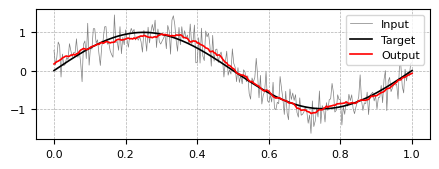

In [9]:
# Generate a clean sine wave and add Gaussian noise
seq_len = 256
t = np.linspace(0, 1, seq_len)                          # Time vector from 0 to 1
x_clean = np.sin(2 * np.pi * t)                         # Clean sine wave (1 Hz)
np.random.seed(0)                                       # Seed for reproducibility
noise_std = 0.3
x_noisy = x_clean + \
    np.random.normal(0.0, noise_std, size=seq_len)      # Add noise

# Apply a simple moving average (low-pass) filter
kernel_size = 21
kernel = np.ones(kernel_size) / kernel_size             # Uniform averaging kernel
x_filtered = np.convolve(x_noisy, kernel, mode='same')  # Apply convolution

# Plot the results
plot_signal_denoise(t, x_noisy, x_clean, x_filtered)

We now reproduce the same smoothing behavior using PyTorch's `nn.Conv1d` layer. To do this, we define a small class that applies a convolution with fixed weights. These weights are set manually to form an averaging filter, which smooths the input signal by taking the mean over neighboring values. This example demonstrates how a standard PyTorch convolutional layer can be used to perform basic signal processing. In later steps, we will remove the fixed weights and instead **learn** the filter automatically by training the layer with data.

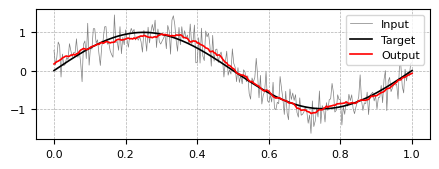

In [10]:
class LowPassFilter(nn.Module):
    """
    A simple low-pass filter implemented as a 1D convolutional layer
    with a fixed averaging (box) kernel.
    """
    def __init__(self, kernel_size=21):
        super().__init__()
        self.conv = nn.Conv1d(
            in_channels=1,
            out_channels=1,
            kernel_size=kernel_size,
            padding="same",
            bias=False
        )
        # Initialize weights with uniform averaging kernel
        self.conv.weight.data = torch.ones(1, 1, kernel_size) / kernel_size

    def forward(self, x):
        return self.conv(x)

# Instantiate the filter
filter = LowPassFilter(kernel_size=21)

# Apply filter to the noisy signal
# (requires 3D input: (batch_size=1, channels=1, length))
x_noisy_tensor = torch.tensor(x_noisy, dtype=torch.float32).view(1, 1, -1)
x_filtered_tensor = filter(x_noisy_tensor)

# Convert filtered output back to 1D for plotting and visualize results
x_filtered = x_filtered_tensor.detach().numpy().flatten()
plot_signal_denoise(t, x_noisy, x_clean, x_filtered)

### Preparing Training Examples

Rather than manually setting fixed filter weights, we now train a convolutional layer to **learn** the filter automatically from data. This is done by providing training examples as input&ndash;output pairs: noisy signals serve as inputs, and their corresponding clean signals act as targets. To create such training data, we generate two NumPy arrays, each of shape `(1000, 256)`, where:

- `X`: contains 1000 clean sine waves of length 256, each with a randomly sampled frequency and phase.
- `Y`: contains the corresponding noisy signals, generated by adding Gaussian noise with a randomly chosen noise level.

We then visualize the first 24 input&ndash;output pairs to examine the variability and structure of the dataset.

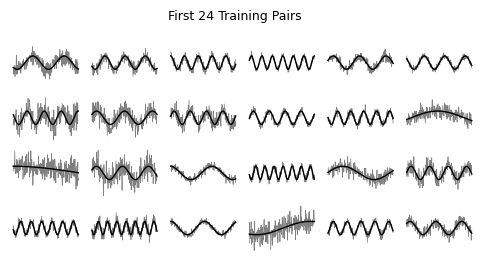

In [11]:
def generate_sine_wave(len_signal=256, num_pairs=1000):
    """
    Generate a dataset of noisy sine waves 
    with varying frequency, phase, and noise levels.

    For each sample:
        - Frequency is drawn uniformly from [0, 8] Hz
        - Phase is drawn uniformly from [0, 1] (in cycles)
        - Gaussian noise is added with std in [0.2, 1.0]

    Args:
        len_signal (int): Number of time steps per signal.
        num_pairs (int): Number of signal pairs to generate.

    Returns:
        t (np.ndarray): Time vector of shape (len_signal,)
        X (np.ndarray): Noisy signals, shape (num_pairs, len_signal)
        Y (np.ndarray): Clean sine signals, shape (num_pairs, len_signal)
    """
    t = np.linspace(0, 1, len_signal)
    X, Y = [], []
    for _ in range(num_pairs):
        freq = np.random.uniform(0, 8)
        phase = np.random.uniform(0, 1)
        noise_std = np.random.uniform(0.2, 1.0)
        y = np.sin(2 * np.pi * (freq * t - phase))
        x = y + np.random.normal(0.0, noise_std, size=len_signal)
        X.append(x)
        Y.append(y)

    return t, np.array(X), np.array(Y)

# Generate dataset and visualize 24 input-output pairs
t, X, Y = generate_sine_wave()
visualize_pairs_24(t, X, Y)

### Training Process

We now define a trainable convolutional module to smooth noisy signals. The model consists of a simple `nn.Conv1d` layer with learnable weights and no bias. Training aims to minimize the **mean squared error** (MSE) between the predicted and clean signals using **stochastic gradient descent**. The dataset is processed over several **epochs**, each consisting of smaller **batches**. Batching helps reduce memory usage and stabilizes updates by averaging gradients. For clarity, we implement manual batching in the next code cell to illustrate the underlying training mechanics. As discussed later, PyTorch's `DataLoader` offers a built-in solution for efficient batching and shuffling.

In [12]:
# Define a learnable low-pass filter using Conv1d
class LearnableLowpass(nn.Module):
    def __init__(self, kernel_size=21):
        super().__init__()
        self.conv = nn.Conv1d(
            in_channels=1,
            out_channels=1,
            kernel_size=kernel_size,
            padding="same",
            bias=False
        )

    def forward(self, x):
        return self.conv(x)

# Instantiate model, loss function, and optimizer
torch.manual_seed(0)  # Ensure reproducible weight initialization
model = LearnableLowpass(kernel_size=21)
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

# Convert to PyTorch tensors and add channel dimension: (batch, channels, length)
X_tensor = torch.tensor(X, dtype=torch.float32).unsqueeze(1)  # (B, 1, T)
Y_tensor = torch.tensor(Y, dtype=torch.float32).unsqueeze(1)  # (B, 1, T)

# Training settings
n_epochs = 50
batch_size = 32
num_samples = len(X_tensor)
num_batches = num_samples // batch_size

# Training loop
for epoch in range(n_epochs):
    # Shuffle the dataset at the start of each epoch
    permutation = torch.randperm(num_samples)
    X_tensor = X_tensor[permutation]
    Y_tensor = Y_tensor[permutation]

    epoch_loss = 0.0
    for i in range(num_batches):
        # Get mini-batch
        start_idx = i * batch_size
        end_idx = start_idx + batch_size
        x_batch = X_tensor[start_idx:end_idx]
        y_batch = Y_tensor[start_idx:end_idx]

        # Forward pass
        y_pred = model(x_batch)
        loss = criterion(y_pred, y_batch)

        # Backward pass and update
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()        
        epoch_loss += loss.item()

    # Print average loss every 10 epochs
    if (epoch + 1) % 10 == 0 or epoch == 0:
        avg_loss = epoch_loss / num_batches
        print(f"Epoch {epoch+1:>2}/{n_epochs} | Avg. Loss: {avg_loss:.6f}")

Epoch  1/50 | Avg. Loss: 0.239165
Epoch 10/50 | Avg. Loss: 0.037469


Epoch 20/50 | Avg. Loss: 0.036559
Epoch 30/50 | Avg. Loss: 0.036499


Epoch 40/50 | Avg. Loss: 0.036538
Epoch 50/50 | Avg. Loss: 0.036582


### Visualizing the Learned Filter and Its Effect on New Data

Next, we examine the results of our learned filter. The filter kernel has a fixed length of 21, which serves as a **hyperparameter** that controls the smoothing capacity of the model. To evaluate the learned behavior, we generate new, **independent** examples using the `generate_sine_wave` function. These include noisy input signals and their corresponding clean targets. We apply the trained model to these new inputs and visualize the filtered outputs alongside the targets. At this stage, we focus solely on visual inspection. A more systematic evaluation, including the use of separate training and test sets, will be introduced in subsequent notebooks when we discuss best practices in assessing data-driven machine learning approaches.

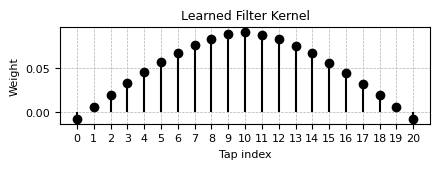

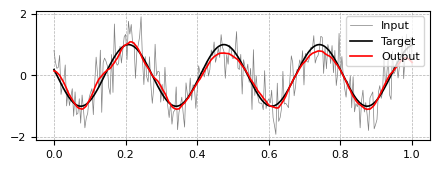

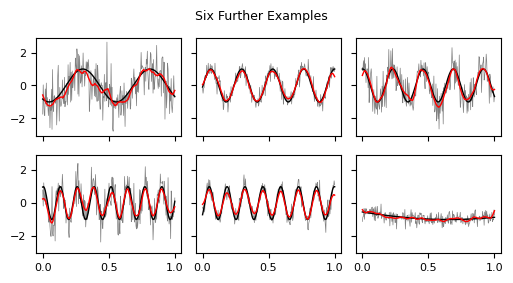

In [13]:
# Plot the learned filter kernel using a stem plot
kernel_weights = model.conv.weight.data.numpy().flatten()
plot_filter_kernel(kernel_weights)

# Generate 7 test signals (noisy + clean)
t, X_test, Y_test = generate_sine_wave(len_signal=256, num_pairs=7)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1) # (B, 1, T)
Y_test_tensor = torch.tensor(Y_test, dtype=torch.float32).unsqueeze(1) # (B, 1, T)

# Apply trained model to test signals
Y_pred = model(X_test_tensor).detach().squeeze().numpy()

# Visualize last example
n = 6
x_input = X_test[n].squeeze()
y_target = Y_test[n].squeeze()
y_pred = Y_pred[n].squeeze()
plot_signal_denoise(t, x_input, y_target, y_pred)

# Visualize first 6 examples
visualize_further_examples_6(t, X_test, Y_test, Y_pred)

<a id='background_low_band_high'></a>
<div style="
  background-color: #C8E6C9A0;
  border: 1px solid #81C784A0;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<h2 style="color:#1B5E20;">Background: Low-, Band-, and High-Pass Filters</h2>

<p style="color:#1B5E20;">
In the convolution framework, a filter is defined by its kernel $h$, which determines how a signal $x$ is transformed via $C_h(x) =h\ast x$. The effect of this transformation depends on the frequency characteristics of $h$.
</p>

<ul style="color:#1B5E20;">
    <li>A <strong>low-pass filter</strong> allows slow (low-frequency) variations in the signal to pass through while suppressing fast (high-frequency) oscillations. Its kernel typically consists of smooth, slowly varying coefficients that act as an averaging or smoothing operator. This is useful for denoising or blurring. We saw this effect earlier when applying a learnable low-pass filter to suppress noise in a synthetic signal.</li>
    <li>A <strong>high-pass filter</strong> does the opposite: it suppresses slow trends and enhances sharp changes and fast oscillations. Its kernel typically contains rapid amplitude changes, cancelling out local means and thereby reducing low-frequency components.</li>
    <li>A <strong>band-pass filter</strong> combines both effects by amplifying a specific range of frequencies while attenuating others. These filters are useful for isolating structured frequency content, such as rhythmic activity or mid-range textures. </li>
</ul>

<p style="color:#1B5E20;">
All these filters can be realized as convolution operators $C_h$, where the choice of kernel $h$ determines the filter's frequency behavior. In practice, such filters are implemented with finite, often symmetric kernels to ensure stability and efficiency. Later in this unit, we will explore a hands-on exercise where we separate a high-frequency signal from a low-frequency component using learned filtering, further illustrating these principles.
</p>
</div>

<a id='pytorch_dataset'></a>  
## Working with Datasets in PyTorch

In supervised learning, we typically train models using many examples, where each example consists of an **input** (e.g., a noisy signal) and a **target** (e.g., the corresponding clean signal). For small-scale tasks, we might store these pairs in arrays and access them manually. However, as the dataset grows or becomes more complex, this approach quickly becomes cumbersome and error prone. To handle such cases more systematically, PyTorch provides the `Dataset` abstraction (contained in `torch.utils.data`). A `Dataset` is a Python object that standardizes how samples are accessed. To create a custom dataset, meaning a user-defined class that specifies how to load your own data, you need to implement two special methods:

- `__len__()` returns the total number of samples  
- `__getitem__(idx)` returns a single input–target pair at index `idx`

This makes it easy for PyTorch to iterate over your data, whether it is fully in memory, read from files, or generated on the fly.

Rather than giving a detailed explanation, we consider a concrete example. In the following code cell, we convert our tensors `X_tensor` and `Y_tensor` into a custom `Dataset`. This makes data access modular, consistent, and ready for more advanced workflows.

In [14]:
# Custom Dataset for (noisy_input, clean_target) signal pairs
class SineWaveDataset(Dataset):
    def __init__(self, X, Y):
        """
        Initialize a dataset for paired signal data.

        Args:
            X (Tensor): Noisy input signals of shape (N, 1, T)
            Y (Tensor): Clean target signals of shape (N, 1, T)
        """
        assert X.shape == Y.shape, "Inputs and targets must have the same shape"
        self.X = X
        self.Y = Y

    def __len__(self):
        # Return the total number of samples
        return self.X.shape[0]

    def __getitem__(self, idx):
        # Retrieve one (input, target) pair at index `idx`
        x = self.X[idx]  # (1, T)
        y = self.Y[idx]  # (1, T)
        return x, y

# Instantiate the dataset
dataset = SineWaveDataset(X_tensor, Y_tensor)

# Print dataset size
print(f"Total number of samples: {len(dataset)}")

# Access and inspect one sample
x_sample, y_sample = dataset[0]
print(f"x_sample shape: {x_sample.shape}")  # Expected: (1, T) with T=256
print(f"y_sample shape: {y_sample.shape}")  # Expected: (1, T) with T=256

# Inspect example values (temporary 3-decimal formatting)
with np.printoptions(precision=3, suppress=True):
    print("First 5 values (input): ", x_sample[0, :5].numpy())
    print("First 5 values (target):", y_sample[0, :5].numpy())
    
    # Loop through the first 3 samples and print short segments
    for i in range(3):
        x, y = dataset[i]
        print(f"Sample {i}: x[0,:2]={x[0,:2].numpy()}, y[0,:2]={y[0,:2].numpy()}")

Total number of samples: 1000
x_sample shape: torch.Size([1, 256])
y_sample shape: torch.Size([1, 256])
First 5 values (input):  [-1.808 -0.068 -0.867 -0.721 -0.607]
First 5 values (target): [-0.456 -0.453 -0.45  -0.446 -0.443]
Sample 0: x[0,:2]=[-1.808 -0.068], y[0,:2]=[-0.456 -0.453]
Sample 1: x[0,:2]=[-0.812 -0.976], y[0,:2]=[-0.638 -0.499]
Sample 2: x[0,:2]=[-0.988 -0.388], y[0,:2]=[-0.553 -0.452]


Wrapping `X_tensor` (noisy inputs) and `Y_tensor` (clean targets), both with shape `(N, 1, T)`, in a custom `Dataset` allows indexed access to individual `(x, y)` pairs. For instance, `dataset[0]` yields `x_sample` and `y_sample`, each of shape `(1, T)`&mdash;representing a single example, not a batch. The `Dataset` abstraction makes data handling modular, enables preprocessing, and scales to large or file-based datasets. Batching and shuffling are managed separately using a `DataLoader`, which we introduce next. For details, we refer to the [primary reference on Datasets](https://pytorch.org/docs/stable/data.html#torch.utils.data.Dataset).

<a id='pytorch_dataloader'></a>  
## Working with Data Loaders in PyTorch

Think of a `Dataset` as a menu: it knows how to prepare and serve a single item when asked. The `DataLoader` acts like a waiter who brings full trays of dishes (batches of samples) efficiently to your training loop. This abstraction allows us to scale up data handling without complicating our code. The `DataLoader` wraps around a `Dataset` and automates several essential tasks:

- **Batching**: Collects multiple samples into mini-batches for efficient parallel computation.
- **Shuffling**: Randomizes sample order at the beginning of each epoch, which helps reduce training bias.
- **Parallel loading**: Uses background workers to load data while the model trains, reducing idle time.

Together, `Dataset` and `DataLoader` separate data preparation from data delivery. This improves modularity, keeps your training code clean, and enables scalable, high-performance workflows—even with large or file-based datasets.

In the code cell below, we construct a `DataLoader` from our custom dataset and use it to iterate over mini-batches—fully prepared for training.

In [15]:
# Create DataLoader for mini-batch processing
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

# Instantiate model, loss function, and optimizer
torch.manual_seed(0)  # Ensure reproducible weight initialization
model = LearnableLowpass(kernel_size=21)
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

# Training loop
n_epochs = 50
for epoch in range(n_epochs):
    epoch_loss = 0.0
    
    for x_batch, y_batch in dataloader:
        # Forward pass
        y_pred = model(x_batch)
        loss = criterion(y_pred, y_batch)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    # Periodically print average loss
    if (epoch + 1) % 10 == 0 or epoch == 0:
        avg_loss = epoch_loss / len(dataloader)
        print(f"Epoch {epoch + 1:>2}/{n_epochs} | Avg. Loss: {avg_loss:.6f}")

Epoch  1/50 | Avg. Loss: 0.235595


Epoch 10/50 | Avg. Loss: 0.037445


Epoch 20/50 | Avg. Loss: 0.036509


Epoch 30/50 | Avg. Loss: 0.036957


Epoch 40/50 | Avg. Loss: 0.036359


Epoch 50/50 | Avg. Loss: 0.036832


In the code above, we use `DataLoader` to feed mini-batches of training data to the model during each epoch. The key parameters used are:

- `dataset`: The `Dataset` object that provides access to `(input, target)` pairs.
- `batch_size=32`: Groups 32 samples into each mini-batch, allowing the model to process multiple examples in parallel.
- `shuffle=True`: Randomly shuffles the dataset at the start of each epoch, improving generalization by varying the order of samples.

Together, these settings make training more efficient and robust by enabling stochastic optimization over batches of data, rather than individual samples.

In summary, we discussed that `Dataset` defines what data you have and how to access it, while `DataLoader` handles how that data is fed to the model—through batching, shuffling, and efficient loading. This separation keeps your code clean, modular, and scalable. For details, we refer to the [main PyTorch website on `torch.utils.data`](https://pytorch.org/docs/stable/data.html).

<a id='exercise_convolution_smooth_edge'></a>
<div style="
  background-color: #B2EBF290;
  border: 1px solid #4DD0E190;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<strong style="color:#006064;">Exercise 1: Convolution for Smoothing and Edge Detection</strong><br>

<p style="color:#006064;">
This exercise explores how convolution filters respond to sharp transitions in a 1D signal.
</p>

<ul style="color:#006064;">
  <li>Define the signal: <code>x = [1, 1, 0, 1, 1, 0, 8, 9, 7, 7, 6, 5, 4]</code>.</li>
  <li>Define two kernels:
    <ul style="color:#006064;">
      <li><code>h_avg = [1/3, 1/3, 1/3]</code> &nbsp; (smoothing / low-pass)</li>
      <li><code>h_edge = [1, 0, -1]</code> &nbsp; (edge detection / high-pass)</li>
    </ul>
  </li>
  <li>Apply <code>F.conv1d</code> with <code>padding="same"</code> to filter <code>x</code> using each kernel.</li>
  <li>Plot the original, smoothed, and edge-detected signals.</li>
    <li>Answer the following questions:
      <ul style="color:#006064;">
        <li>How does smoothing modify the sharp transition?</li>
        <li>Where and why does the edge detector respond?</li>
        <li>How does zero-padding at the boundaries affect the result?</li>
      </ul>
    </li>
</ul>
</div>

In [16]:
# Your Solution

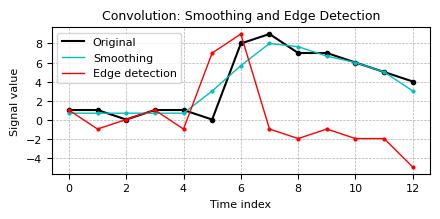

* Smoothing reduces sharp transitions by averaging neighbors.
* The edge detector reacts to abrupt changes
  (e.g., when the signal rises from 0 to 8).
* Zero-padding can cause edge boundary artifacts
 (e.g., spurious negative values at the end).


In [17]:
# Run and show output of the reference solution
exercise_convolution_smooth_edge()

<a id='exercise_conv1d_parameters'></a>
<div style="
  background-color: #B2EBF290;
  border: 1px solid #4DD0E190;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<strong style="color:#006064;">Exercise 2: Understanding Key Parameters of the PyTorch 1D Convolution Layer</strong><br>

<p style="color:#006064;">
This exercise helps you explore how key settings in 1D convolutions influence the output shape, temporal resolution, and number of model parameters. Start with a batch of random signals using <code>x = torch.randn(B, C, T)</code>, for example, with batch size <code>B=3</code> (three examples), number of channels <code>C=2</code> (e.g., stereo audio), and signal length <code>T=15</code> (time steps). Then apply several convolution layers with different parameter settings to observe their effects.
</p>

<ul style="color:#006064;">
  <li><code>nn.Conv1d(in_channels=C, out_channels=3, kernel_size=5, stride=1, padding=0, bias=False)</code></li>
  <li><code>nn.Conv1d(in_channels=C, out_channels=3, kernel_size=5, stride=1, padding=0)</code></li> 
  <li><code>nn.Conv1d(in_channels=C, out_channels=3, kernel_size=5, stride=3, padding=2)</code></li>       
  <li><code>nn.Conv1d(in_channels=C, out_channels=7, kernel_size=5, stride=1, padding=2, dilation=3)</code></li> 
</ul>

<p style="color:#006064;">
Perform the following tasks:
</p>
<ul style="color:#006064;">
  <li>For each case, print the output shape after applying the convolution layer.</li>
  <li>Count and print the total number of model parameters. In particular, analyze how weights and bias terms depend on <code>in_channels</code> and <code>out_channels</code>.</li>
  <li>Apply a convolution with <code>stride &gt; kernel_size</code> and describe how it affects resolution.</li>
</ul>
</div>

In [18]:
# Your Solution

In [19]:
# Run and show output of the reference solution
exercise_conv1d_parameters()

Input shape: torch.Size([3, 2, 15])

Layer 1: Conv1d(2, 3, kernel_size=(5,), stride=(1,), bias=False)
  Output shape: torch.Size([3, 3, 11])
  Weights shape: torch.Size([3, 2, 5]) -> total: 30
  Bias shape: None -> total: 0
  Total parameters: 30

Layer 2: Conv1d(2, 3, kernel_size=(5,), stride=(1,))
  Output shape: torch.Size([3, 3, 11])
  Weights shape: torch.Size([3, 2, 5]) -> total: 30
  Bias shape: torch.Size([3]) -> total: 3
  Total parameters: 33

Layer 3: Conv1d(2, 3, kernel_size=(5,), stride=(3,), padding=(2,))
  Output shape: torch.Size([3, 3, 5])
  Weights shape: torch.Size([3, 2, 5]) -> total: 30
  Bias shape: torch.Size([3]) -> total: 3
  Total parameters: 33

Layer 4: Conv1d(2, 7, kernel_size=(5,), stride=(1,), padding=(2,), dilation=(3,))
  Output shape: torch.Size([3, 7, 7])
  Weights shape: torch.Size([7, 2, 5]) -> total: 70
  Bias shape: torch.Size([7]) -> total: 7
  Total parameters: 77

Case: stride > kernel_size:
Layer 5: Conv1d(2, 3, kernel_size=(3,), stride=(5,))


<a id='note_conv1d_parameters'></a>
<div style="
  background-color: #FFE0B2A0;
  border: 1px solid #FFC671A0;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<p style="color:#E65100;">
<strong>Note:</strong>  
In <code>nn.Conv1d</code>, each output channel learns a separate kernel for every input channel, resulting in <code>in_channels × out_channels × kernel_size</code> weights. Consequently, the number of weights grows linearly with both <code>in_channels</code> and <code>out_channels</code>. One may expect that each input&ndash;output pair might need its own bias. However, there is exactly <strong>one bias term per output channel</strong>, and not per input channel. This is because all convolutions across input channels are summed before the bias is applied. The bias then acts as a shared offset for the entire output channel. Having multiple biases per output channel would be redundant and unnecessarily increase the parameter count.
</p>

<style>
/* Force left-aligned tables in classic HTML export */
table, th, td {
    text-align: left !important;
}
</style>

<table style="width:100%; border-collapse: collapse; margin-top: 10px; table-layout: fixed;">
  <colgroup>
    <col style="width:15%; text-align:left">
    <col style="width:37%; text-align:left">
    <col style="width:48%; text-align:left">  
  </colgroup>
  <thead>
    <tr style="background-color: #e3e3e3; text-align: left;">
      <th style="border: 1px solid #ccc; padding: 6px;">Parameter</th>
      <th style="border: 1px solid #ccc; padding: 6px;">Depends On</th>
      <th style="border: 1px solid #ccc; padding: 6px;">Explanation</th>
    </tr>
  </thead>
  <tbody>
    <tr style="background-color: white; transition: none;">
      <td style="border: 1px solid #ccc; padding: 6px;"><strong>Weights</strong></td>
      <td style="border: 1px solid #ccc; padding: 6px;"><code>in_channels × out_channels × kernel_size</code></td>
      <td style="border: 1px solid #ccc; padding: 6px;">Each output channel uses a separate kernel for each input channel.</td>
    </tr>
    <tr style="background-color: white; transition: none;">
      <td style="border: 1px solid #ccc; padding: 6px;"><strong>Biases</strong></td>
      <td style="border: 1px solid #ccc; padding: 6px;"><code>out_channels</code></td>
      <td style="border: 1px solid #ccc; padding: 6px;">One bias per output channel, applied after summing across input channels.</td>
    </tr>
  </tbody>
</table>  
</div>

<a id='exercise_convolution_freq_separation'></a>
<div style="
  background-color: #B2EBF290;
  border: 1px solid #4DD0E190;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<strong style="color:#006064;">Exercise 3: Learning to Separate Low- and High-Frequency Components</strong><br>

<p style="color:#006064;">
In this exercise, you will train a convolutional kernel to extract the high-frequency portion of a signal composed of both low- and high-frequency sinusoids, combined with noise.
</p>

<ul style="color:#006064;">
  <li>Generate synthetic signals of length <code>T = 256</code> (corresponding to 1 second), where each signal is constructed by summing:
    <ul style="color:#006064;">
      <li>A low-frequency sinusoid with amplitude 1, random frequency between 2 and 6 Hz, and a random phase</li>
      <li>A high-frequency sinusoid with amplitude 0.5, random frequency between 12 and 20 Hz, and a random phase</li>
      <li>Gaussian noise using <code>np.random.normal(0, 0.5, T)</code></li>
    </ul>
  </li>
  <li>Create $1000$ such signal pairs. For each, store:
    <ul style="color:#006064;">
      <li><code>X</code>: the combined signal (low + high + noise)</li>
      <li><code>Y</code>: the clean high-frequency sinusoid (high only)</li>
    </ul>
  </li>
  <li>Wrap the dataset in a PyTorch <code>Dataset</code> and use a <code>DataLoader</code> with <code>batch_size = 32</code> and shuffling enabled.</li>
  <li>Define a one-layer convolutional model with <code>kernel_size = 21</code> and <code>bias = False</code>.
  </li>
  <li>Train the model to predict <code>Y</code> from <code>X</code> using the mean squared error (MSE) loss. Monitor the training loss over epochs.</li>
  <li>After training:
    <ul style="color:#006064;">
      <li>Plot the learned kernel weights.</li>
      <li>Apply the model to new, unseen test examples and compare its prediction with the true high-frequency component.</li>
    </ul>
  </li>
</ul>
<p style="color:#006064;">
This task illustrates how a convolutional filter can learn frequency-selective behavior.
</p>
</div>

In [20]:
# Your Solution

Epoch  1/50 | Avg. Loss: 0.142760


Epoch 10/50 | Avg. Loss: 0.030263


Epoch 20/50 | Avg. Loss: 0.027667


Epoch 30/50 | Avg. Loss: 0.027579


Epoch 40/50 | Avg. Loss: 0.027543


Epoch 50/50 | Avg. Loss: 0.027485


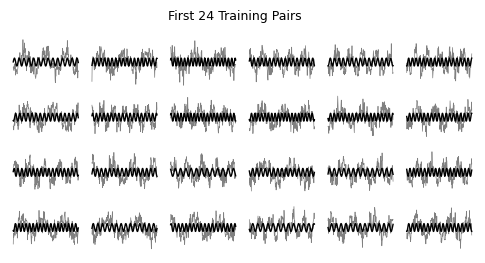

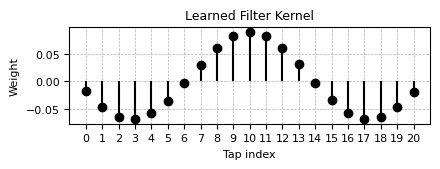

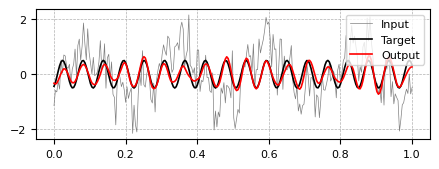

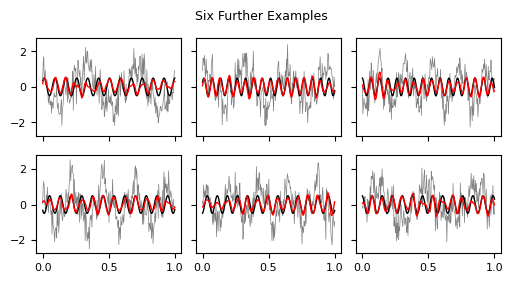

In [21]:
# Run and show output of the reference solution
exercise_convolution_freq_separation()

<div>
<a href="https://opensource.org/licenses/MIT"><img src="data_layout/PCPT_License.png" width=100% style="float: right;" alt="PCPT License"></a>
</div>